# Stock Price Forecaster
Predicting future stock prices using a 2-layer LSTM neural network built with TensorFlow/Keras.

**Goal:** Train on 5 years of historical closing prices and forecast the next 7 days.  
**Stock:** Apple Inc. (AAPL)  
**Model:** LSTM (Long Short-Term Memory)  
**Deployment:** FastAPI + Gradio on HuggingFace Spaces

In [1]:
!pip install yfinance plotly -q

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import math

## 2. Fetch Stock Data
Using yfinance to pull 5 years of Apple (AAPL) daily closing prices directly from Yahoo Finance.
No dataset download needed — data is fetched live.

In [3]:
df = yf.download("AAPL", start="2018-01-01", end="2024-01-01", auto_adjust=True)
df = df[["Close"]]
df.columns = ["Close"]       # fix multi-level column issue from recent yfinance
df.dropna(inplace=True)

print(f"Total trading days : {len(df)}")
print(f"Date range         : {df.index[0].date()} → {df.index[-1].date()}")
df.head()

[*********************100%***********************]  1 of 1 completed

Total trading days : 1509
Date range         : 2018-01-02 → 2023-12-29


,Close
Date,
2018-01-02,40.267071
2018-01-03,40.260063
2018-01-04,40.447067
2018-01-05,40.907574
2018-01-08,40.755619


## 3. Exploratory Data Analysis (EDA)
Before modelling, we explore the data to understand its shape, trends, and volatility.

In [4]:
df.describe()

,Close
count,1509.000000
mean,107.624452
std,50.839639
min,33.736996
25%,51.142414
50%,120.241333
75%,149.942215
max,195.892624


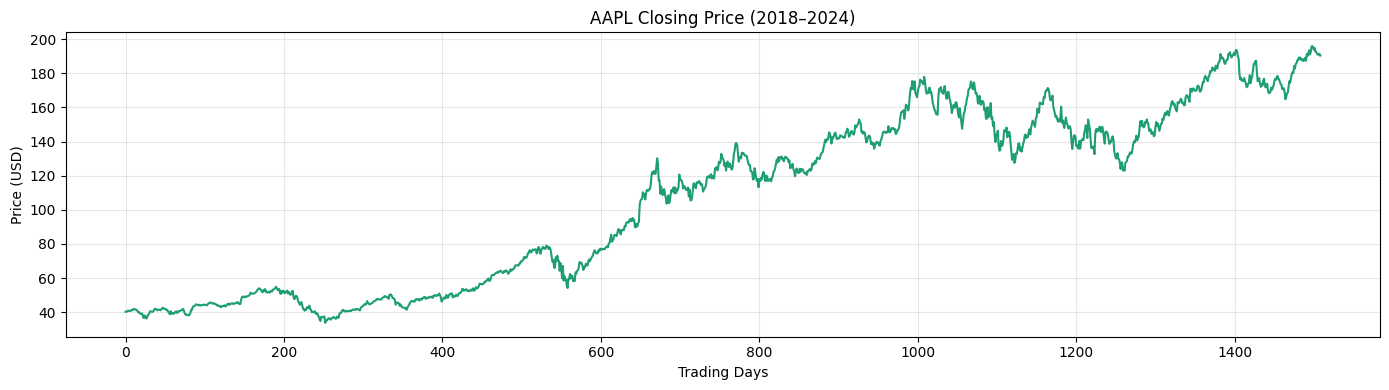

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df["Close"].values, color="#1D9E75", linewidth=1.5)
plt.title("AAPL Closing Price (2018–2024)")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

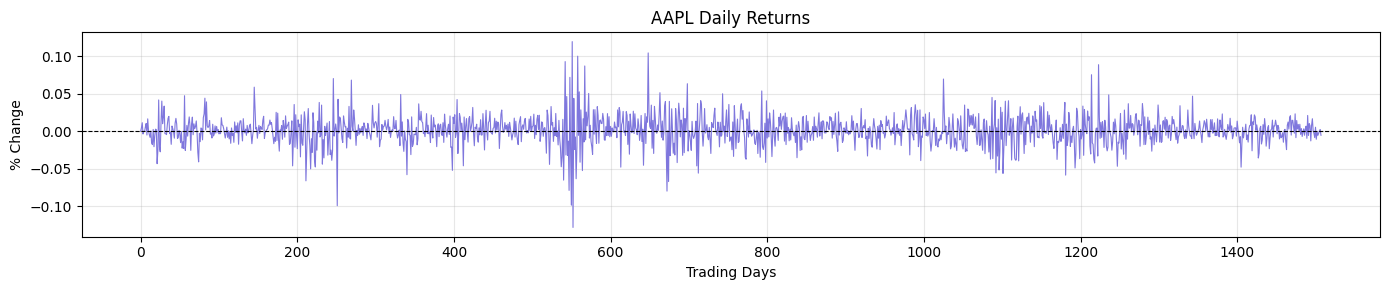

Average daily return : 0.123%
Volatility (std dev) : 1.995%


In [6]:
daily_returns = df["Close"].pct_change().dropna()

plt.figure(figsize=(14, 3))
plt.plot(daily_returns.values, color="#7F77DD", linewidth=0.8)
plt.title("AAPL Daily Returns")
plt.xlabel("Trading Days")
plt.ylabel("% Change")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average daily return : {daily_returns.mean()*100:.3f}%")
print(f"Volatility (std dev) : {daily_returns.std()*100:.3f}%")

## 4. Preprocessing

Two key steps:
- **Normalize** prices to [0,1] range using MinMaxScaler — LSTMs train better on small values
- **Create sequences** — we use the last 60 trading days to predict the next day's price (sliding window approach)

In [7]:
SEQUENCE_LEN = 60

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df[["Close"]])

# create sliding window sequences
X, y = [], []
for i in range(SEQUENCE_LEN, len(scaled)):
    X.append(scaled[i - SEQUENCE_LEN:i, 0])
    y.append(scaled[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))   # (samples, timesteps, features)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X shape : (1449, 60, 1)
y shape : (1449,)


In [8]:
split   = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 1159
Testing samples  : 290


## 5. Build LSTM Model

2-layer LSTM with Dropout to prevent overfitting.
- Layer 1: 64 LSTM units, returns sequences
- Layer 2: 64 LSTM units
- Output: single neuron predicting next day's price

In [9]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LEN, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train Model

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.0247 - val_loss: 0.0089
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0030 - val_loss: 0.0049
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027 - val_loss: 0.0033
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 0.0030
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0018 - val_loss: 0.0035
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

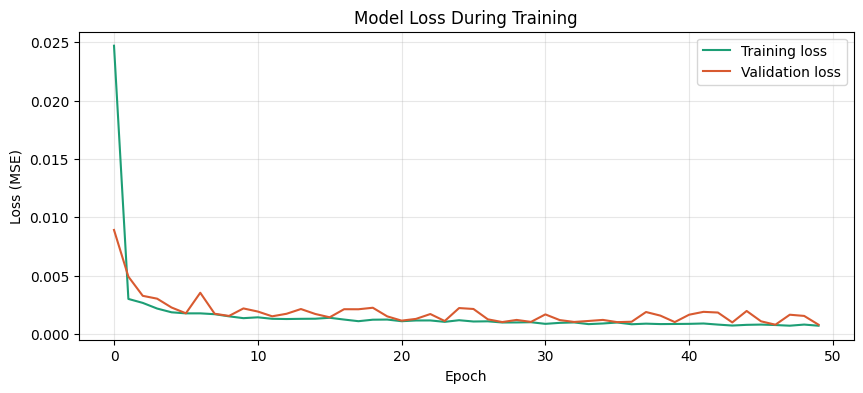

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="Training loss",   color="#1D9E75")
plt.plot(history.history["val_loss"], label="Validation loss", color="#D85A30")
plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Evaluate Model
Testing on unseen data. We inverse-transform predictions back to actual USD prices before computing metrics.

In [12]:
predictions_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)
actual      = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = math.sqrt(mean_squared_error(actual, predictions))
mae  = mean_absolute_error(actual, predictions)

print(f"RMSE : ${rmse:.2f}")
print(f"MAE  : ${mae:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
RMSE : $4.20
MAE  : $3.44


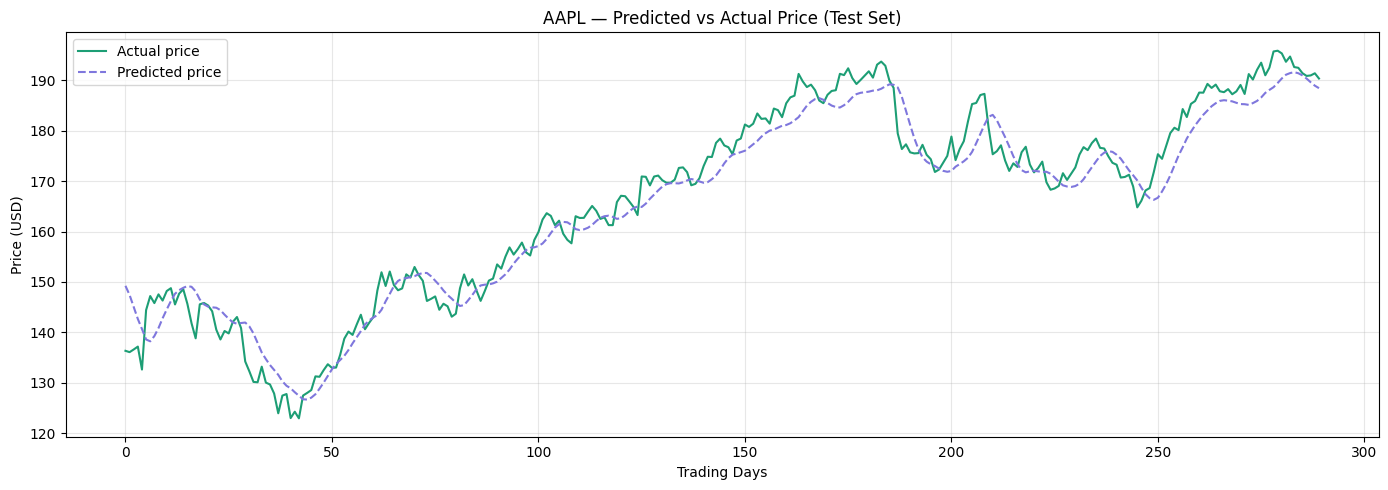

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(actual,      label="Actual price",    color="#1D9E75", linewidth=1.5)
plt.plot(predictions, label="Predicted price", color="#7F77DD", linewidth=1.5, linestyle="--")
plt.title("AAPL — Predicted vs Actual Price (Test Set)")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# check what data is being used as seed
print(f"Total rows in df: {len(df)}")
print(f"Last date in df: {df.index[-1].date()}")
print(f"Seed start date: {df.index[-SEQUENCE_LEN].date()}")
print(f"Seed end date:   {df.index[-1].date()}")
print(f"Seed length:     {SEQUENCE_LEN} days")
print(f"\nLast 5 actual closing prices used as seed:")
print(df["Close"].tail(5))

Total rows in df: 1509
Last date in df: 2023-12-29
Seed start date: 2023-10-05
Seed end date:   2023-12-29
Seed length:     60 days

Last 5 actual closing prices used as seed:
Date
2023-12-22    191.433090
2023-12-26    190.889236
2023-12-27    190.988113
2023-12-28    191.413315
2023-12-29    190.375092
Name: Close, dtype: float64


## 8. Forecast Next 7 Days
Using the last 60 days as a seed, we predict autoregressively — each prediction is fed back as input for the next step.

In [15]:
FORECAST_DAYS = 7

last_sequence = scaler.transform(df[["Close"]][-SEQUENCE_LEN:])
current_seq   = last_sequence.reshape(1, SEQUENCE_LEN, 1)

forecast_preds = []
for _ in range(FORECAST_DAYS):
    pred = model.predict(current_seq, verbose=0)[0][0]
    forecast_preds.append(pred)
    current_seq = np.append(current_seq[:, 1:, :], [[[pred]]], axis=1)

forecast_prices = scaler.inverse_transform(
    np.array(forecast_preds).reshape(-1, 1)
).flatten()

print("7-Day Price Forecast:")
for i, price in enumerate(forecast_prices, 1):
    print(f"  Day {i}: ${price:.2f}")

7-Day Price Forecast:
  Day 1: $188.01
  Day 2: $187.35
  Day 3: $186.59
  Day 4: $185.78
  Day 5: $184.95
  Day 6: $184.14
  Day 7: $183.34


In [16]:
last_90        = df[-90:]
last_date      = df.index[-1]
forecast_dates = pd.date_range(last_date, periods=FORECAST_DAYS + 1, freq="B")[1:]

# connect last historical point to first forecast point
connect_x = [last_90.index[-1]]          + list(forecast_dates)
connect_y = [float(last_90["Close"].iloc[-1])] + list(forecast_prices)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=last_90.index,
    y=last_90["Close"].values.flatten(),
    mode="lines",
    name="Historical (last 90 days)",
    line=dict(color="#1D9E75", width=2)
))

fig.add_trace(go.Scatter(
    x=connect_x,
    y=connect_y,
    mode="lines+markers",
    name=f"{FORECAST_DAYS}-Day Forecast",
    line=dict(color="#D85A30", width=2, dash="dash"),
    marker=dict(size=8)
))

fig.update_layout(
    title="AAPL — 7-Day Price Forecast",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)

fig.show()

## 9. Save Model

In [17]:
# model.save("lstm_stock_model.keras")

# from google.colab import files
# files.download("lstm_stock_model.keras")